In [1]:
import os
import cv2
import torch
import numpy as np
import torchvision.transforms as T
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.transforms import functional as TF

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ── Paths: update these to your saved weight locations ────────────────────────
RCNN_WEIGHTS_PATH      = "E:/Github/Thyroid nodule detection/RCNN Model data/Best_wei/best_fasterrcnn.pth"
DENSENET_WEIGHTS_PATHS = [
    "E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold1.pth",
    "E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold2.pth",
    "E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold3.pth",
]
RESNET_WEIGHTS_PATHS = [
    "E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold1.pth",
    "E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold2.pth",
    "E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold3.pth",
]

# ── Preprocessing constants (IDENTICAL to training) ───────────────────────────
CLAHE_CLIP  = 2.0
CLAHE_GRID  = (8, 8)
CROP_MARGIN = 30
RESIZE_SIZE = 224

In [4]:
# ── Class labels ──────────────────────────────────────────────────────────────
CLASS_NAMES      = {0: "benign", 1: "malignant"}
RCNN_LABEL_NAMES = {1: "benign", 2: "malignant"}   # RCNN: 0=bg, 1=benign, 2=malignant
 
# ── Detection thresholds ──────────────────────────────────────────────────────
RCNN_SCORE_THRESH = 0.4
NMS_IOU_THRESH    = 0.3
MALIGNANT_THRESH  = 0.32

In [5]:
def apply_clahe(img_bgr):
    """CLAHE + unsharp mask -- identical to DenseNet & ResNet training."""
    lab       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b   = cv2.split(lab)
    clahe     = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    l_clahe   = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge([l_clahe, a, b]), cv2.COLOR_LAB2BGR)
    blurred   = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=2)
    sharpened = cv2.addWeighted(img_clahe, 1.3, blurred, -0.3, 0)
    return sharpened
 
 
def load_and_preprocess(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot open image: {image_path}")
    img_bgr = apply_clahe(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    return img_bgr, img_pil

In [6]:
def build_rcnn(num_classes=3):
    return fasterrcnn_resnet50_fpn_v2(weights=None, num_classes=num_classes)
 
 
def build_densenet():
    """Dropout(0.5) + Linear head -- matches training."""
    model = models.densenet121(weights=None)
    num_features     = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_features, 2)
    )
    return model
 
 
def build_resnet50():
    """Linear(2048->512)->ReLU->Dropout(0.3)->Linear(512->2) -- matches training."""
    model = models.resnet50(weights=None)
    num_features = model.fc.in_features   # 2048
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 2)
    )
    return model

In [7]:
def load_rcnn(weights_path):
    model = build_rcnn()
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print(f"[RCNN]     Loaded: {weights_path}")
    return model
 
 
def load_densenet_ensemble(weights_paths):
    ensemble = []
    for path in weights_paths:
        m = build_densenet()
        m.load_state_dict(torch.load(path, map_location=DEVICE))
        m.to(DEVICE)
        m.eval()
        ensemble.append(m)
        print(f"[DenseNet] Loaded: {path}")
    return ensemble
 
 
def load_resnet_ensemble(weights_paths):
    ensemble = []
    for path in weights_paths:
        m = build_resnet50()
        m.load_state_dict(torch.load(path, map_location=DEVICE))
        m.to(DEVICE)
        m.eval()
        ensemble.append(m)
        print(f"[ResNet50] Loaded: {path}")
    return ensemble

In [8]:
val_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
 
tta_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.FiveCrop(int(RESIZE_SIZE * 0.9)),
    T.Lambda(lambda crops: torch.stack([
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])(T.ToTensor()(c))
        for c in crops
    ]))
])
 

In [9]:
def detect_nodules(rcnn_model, img_pil, min_thresh=0.20, verbose=True):
    tensor = TF.to_tensor(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        preds = rcnn_model(tensor)[0]
    
    boxes  = preds["boxes"].cpu()
    labels = preds["labels"].cpu()
    scores = preds["scores"].cpu()

    thresh = RCNN_SCORE_THRESH  # Start at 0.4

    while thresh >= min_thresh:
        keep = scores >= thresh
        if keep.any():  # Found at least one box
            if verbose:
                print(f"[RCNN] Threshold used: {thresh:.2f}  |  Detections: {keep.sum().item()}")
            return boxes[keep], labels[keep], scores[keep]
        # No boxes found, reduce threshold and try again
        thresh = round(thresh - 0.05, 2)
        if verbose:
            print(f"[RCNN] No detections at {thresh + 0.05:.2f}, trying {thresh:.2f}...")

    # Nothing found even at min_thresh
    if verbose:
        print(f"[RCNN] No detections found even at minimum threshold ({min_thresh:.2f})")
    return boxes[scores >= min_thresh], labels[scores >= min_thresh], scores[scores >= min_thresh]

In [10]:
def apply_nodule_nms(boxes, labels, scores):
    if len(boxes) == 0:
        return []
    order  = scores.argsort(descending=True)
    boxes  = boxes[order]
    labels = labels[order]
    scores = scores[order]
    kept   = []
    active = [True] * len(boxes)
    for i in range(len(boxes)):
        if not active[i]:
            continue
        kept.append((boxes[i], labels[i], scores[i]))
        for j in range(i + 1, len(boxes)):
            if not active[j]:
                continue
            iou = box_iou(boxes[i].unsqueeze(0), boxes[j].unsqueeze(0)).item()
            if iou >= NMS_IOU_THRESH:
                active[j] = False
    return kept

In [11]:
def crop_nodule(img_pil, box):
    W, H    = img_pil.size
    x1, y1, x2, y2 = map(int, box.tolist())
    x1 = max(0, x1 - CROP_MARGIN)
    y1 = max(0, y1 - CROP_MARGIN)
    x2 = min(W, x2 + CROP_MARGIN)
    y2 = min(H, y2 + CROP_MARGIN)
    return img_pil.crop((x1, y1, x2, y2)), (x1, y1, x2, y2)

In [12]:
def classify_crop(crop_pil, densenet_models, resnet_models):
    crop_rgb   = crop_pil.convert("RGB")
    probs_list = []
 
    # DenseNet x3: single pass
    tensor_dn = val_transform(crop_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        for m in densenet_models:
            out   = m(tensor_dn)
            probs = torch.softmax(out, dim=1)[0].cpu().numpy()
            probs_list.append(probs)
 
    # ResNet50 x3: 5-crop TTA
    tensor_rn = tta_transform(crop_rgb).to(DEVICE)   # (5, 3, H, W)
    with torch.no_grad():
        for m in resnet_models:
            out      = m(tensor_rn)
            probs_5  = torch.softmax(out, dim=1)
            avg_prob = probs_5.mean(dim=0).cpu().numpy()
            probs_list.append(avg_prob)
 
    # Average all 6
    avg_probs = np.mean(probs_list, axis=0)
    mal_prob  = float(avg_probs[1])
    cnn_label = "malignant" if mal_prob >= MALIGNANT_THRESH else "benign"
    return cnn_label, mal_prob, probs_list

In [13]:
def fuse_predictions(cnn_label, mal_prob, rcnn_label_int):
    rcnn_label = RCNN_LABEL_NAMES.get(rcnn_label_int, "unknown")
    agree      = (cnn_label == rcnn_label)
    if agree:
        return cnn_label, mal_prob, f"CNN+RCNN agree -> {cnn_label}"
    if 0.35 <= mal_prob <= 0.50:
        return rcnn_label, mal_prob, f"Marginal CNN ({mal_prob:.2f}), RCNN overrides -> {rcnn_label}"
    else:
        return cnn_label, mal_prob, f"CNN confident ({mal_prob:.2f}), overrides RCNN -> {cnn_label}"
 

In [14]:
BOX_COLORS = {"benign": (0, 220, 0), "malignant": (220, 0, 0)}
 
 
def draw_results(img_bgr, nodule_results):
    out = img_bgr.copy()
    for res in nodule_results:
        x1, y1, x2, y2 = res["box"]
        label  = res["final_label"]
        prob   = res["mal_prob"]
        color  = BOX_COLORS.get(label, (200, 200, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        conf  = prob if label == "malignant" else 1 - prob
        text  = f"{label.upper()}  {conf:.2f}"
        (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        ty    = max(y1 - 8, th + 4)
        cv2.rectangle(out, (x1, ty - th - 4), (x1 + tw + 4, ty + baseline), (0, 0, 0), -1)
        cv2.putText(out, text, (x1 + 2, ty - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2, cv2.LINE_AA)
    return out
 
 
def show_output(img_bgr, nodule_results, image_path):
    vis     = draw_results(img_bgr, nodule_results)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(vis_rgb)
    ax.axis("off")
    notes = " | ".join([f"Nodule {i+1}: {r['note']}" for i, r in enumerate(nodule_results)])
    ax.set_title(notes, fontsize=9, wrap=True)
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0],[0], color=(0, 220/255, 0), linewidth=2, label="Benign"),
        Line2D([0],[0], color=(220/255, 0, 0), linewidth=2, label="Malignant"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=10)
    plt.suptitle(f"Thyroid Nodule Pipeline -- {os.path.basename(image_path)}", fontsize=12)
    plt.tight_layout()
    plt.show()
    return vis

In [15]:
def run_pipeline(image_path, rcnn_model, densenet_models, resnet_models,
                 save_path=None, verbose=True):
 
    img_bgr, img_pil = load_and_preprocess(image_path)
    W, H = img_pil.size
    if verbose:
        print(f"\n[Pipeline] Image: {image_path}  ({W}x{H})")
 
    boxes, labels, scores = detect_nodules(rcnn_model, img_pil)
    if verbose:
        print(f"[RCNN] Raw detections: {len(boxes)}")
        for i in range(len(boxes)):
            print(f"  box {i}: {boxes[i].tolist()}  "
                  f"label={RCNN_LABEL_NAMES.get(labels[i].item(),'?')}  "
                  f"score={scores[i].item():.3f}")
 
    if len(boxes) == 0:
        print("[Pipeline] No nodules detected above threshold. Stopping.")
        return []
 
    kept = apply_nodule_nms(boxes, labels, scores)
    if verbose:
        print(f"[NMS] Kept {len(kept)} nodule(s) after overlap handling")
 
    nodule_results = []
    for idx, (box, rcnn_label_t, score_t) in enumerate(kept):
        crop_pil, crop_coords          = crop_nodule(img_pil, box)
        cnn_label, mal_prob, per_model = classify_crop(crop_pil, densenet_models, resnet_models)
        rcnn_label_int                 = rcnn_label_t.item()
        final_label, mal_prob, note    = fuse_predictions(cnn_label, mal_prob, rcnn_label_int)
 
        if verbose:
            rcnn_name = RCNN_LABEL_NAMES.get(rcnn_label_int, "?")
            dn_probs  = [f"{p[1]:.3f}" for p in per_model[:3]]
            rn_probs  = [f"{p[1]:.3f}" for p in per_model[3:]]
            print(f"\n[Nodule {idx+1}]")
            print(f"  Box              : {crop_coords}")
            print(f"  RCNN label       : {rcnn_name}  (score={score_t.item():.3f})")
            print(f"  DenseNet mal_prob: {dn_probs}  (folds 1-3)")
            print(f"  ResNet50 mal_prob: {rn_probs}  (folds 1-3)")
            print(f"  Ensemble avg     : {mal_prob:.3f}")
            print(f"  CNN decision     : {cnn_label}")
            print(f"  Final decision   : {final_label.upper()}")
            print(f"  Note             : {note}")
 
        nodule_results.append({
            "box"        : crop_coords,
            "final_label": final_label,
            "mal_prob"   : mal_prob,
            "note"       : note,
        })
 
    vis = show_output(img_bgr, nodule_results, image_path)
 
    if save_path:
        cv2.imwrite(save_path, draw_results(img_bgr, nodule_results))
        print(f"\n[Pipeline] Output saved to: {save_path}")
 
    return nodule_results

Loading models...
[RCNN]     Loaded: E:/Github/Thyroid nodule detection/RCNN Model data/Best_wei/best_fasterrcnn.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold1.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold2.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold3.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold1.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold2.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold3.pth

All models ready.

[Pipeline] Image: E:\Github\Thyroid nodule detection\Data\000020.jpg  (498x429)
[RCNN] No detections at 0.40, trying 0.35...
[RCNN] No detections at 0.35, trying 0.30...
[RCNN] Threshold used: 0.30  |  D

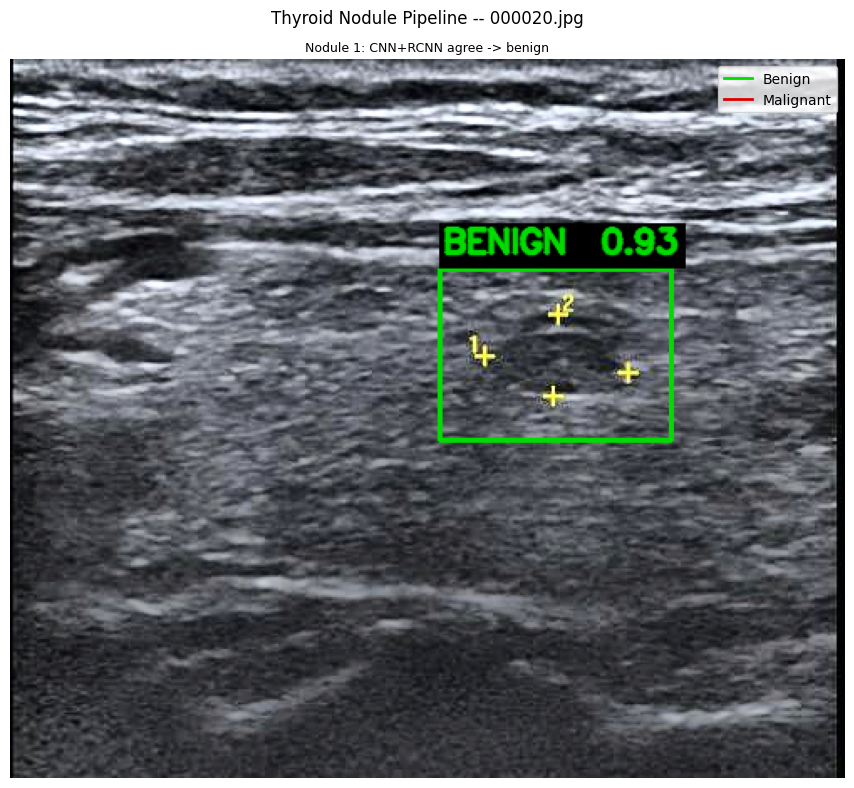


[Pipeline] Output saved to: E:\Github\Thyroid nodule detection\Data\000020_result.jpg


In [16]:
print("Loading models...")
rcnn_model      = load_rcnn(RCNN_WEIGHTS_PATH)
densenet_models = load_densenet_ensemble(DENSENET_WEIGHTS_PATHS)
resnet_models   = load_resnet_ensemble(RESNET_WEIGHTS_PATHS)
print("\nAll models ready.")
 
# Set your image path here
img_path = r"E:\Github\Thyroid nodule detection\Data\000020.jpg"   # <- change this
 
results = run_pipeline(
    image_path      = img_path,
    rcnn_model      = rcnn_model,
    densenet_models = densenet_models,
    resnet_models   = resnet_models,
    save_path       = img_path.replace(".jpg", "_result.jpg"),
    verbose         = True,
)

---
## Nodule Boundary Detection
**Stage 2:** After R-CNN detection, we refine the nodule boundary inside each bounding box using:
1. **Ultrasound-specific preprocessing** — CLAHE, bilateral filter, anisotropic speckle reduction
2. **Canny edge detection** — finds strong gradient edges in the enhanced ROI
3. **Deformable contour (snake) via greedy algorithm** — evolves an initial ellipse inward/outward to lock onto the true nodule wall

All processing is strictly **inside the R-CNN bounding box** for precision.

In [17]:
# ── Ultrasound ROI Enhancement ────────────────────────────────────────────
def enhance_us_roi(roi_bgr):
    """
    Ultrasound-specific enhancement pipeline for a single ROI patch.
    Steps:
      1. Convert to grayscale
      2. Bilateral filter  – removes speckle while preserving edges
      3. CLAHE             – boosts local contrast (reuses pipeline constants)
      4. Median filter     – cleans residual salt-and-pepper noise
    Returns the enhanced single-channel image (uint8).
    """
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

    # Bilateral filter: speckle suppression with edge preservation
    bilateral = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    # CLAHE: local contrast enhancement (reuse pipeline constants)
    clahe   = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    enhanced = clahe.apply(bilateral)

    # Median blur: final noise removal
    denoised = cv2.medianBlur(enhanced, ksize=3)

    return denoised


In [18]:
# ── Canny Edge Detection (inside bounding box only) ──────────────────────
def detect_edges_canny(enhanced_gray, low_thresh=30, high_thresh=80,
                        aperture_size=3, use_l2=True):
    """
    Applies Canny on an already-enhanced grayscale ROI.
    Ultrasound images have low SNR, so we use:
      - Additional Gaussian blur before Canny to suppress speckle
      - Conservative low threshold (avoids fragmenting real edges)
      - L2 gradient norm for better angular accuracy

    Args:
        enhanced_gray : uint8 grayscale ROI
        low_thresh    : Canny lower hysteresis threshold  (default 30)
        high_thresh   : Canny upper hysteresis threshold  (default 80)
        aperture_size : Sobel kernel size (3 or 5)        (default 3)
        use_l2        : True → L2 gradient, False → L1    (default True)

    Returns:
        edges : uint8 binary edge map (same size as input)
    """
    # Extra Gaussian smoothing – critical for speckled US images
    blurred = cv2.GaussianBlur(enhanced_gray, (5, 5), sigmaX=1.5)
    edges   = cv2.Canny(blurred,
                         threshold1    = low_thresh,
                         threshold2    = high_thresh,
                         apertureSize  = aperture_size,
                         L2gradient    = use_l2)
    return edges


In [19]:
# ── Deformable Contour – Greedy Snake Algorithm ───────────────────────────
def _image_energy(enhanced_gray):
    """
    External energy map derived from image gradient magnitude.
    High energy at edges → snake is attracted toward boundaries.
    """
    # Gradient magnitude via Sobel
    gx  = cv2.Sobel(enhanced_gray, cv2.CV_64F, 1, 0, ksize=3)
    gy  = cv2.Sobel(enhanced_gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)

    # Smooth the energy map to give the snake a wider basin of attraction
    mag = cv2.GaussianBlur(mag, (21, 21), sigmaX=5)

    # Normalise to [0, 1]
    if mag.max() > 0:
        mag = mag / mag.max()

    return mag  # shape: (H, W), float64


def _internal_energy(contour):
    """
    Internal energy terms:
      E_elastic  – penalises point spacing inconsistency (1st differences)
      E_curvature– penalises sharp bending              (2nd differences)
    Returns arrays of shape (N,) for both terms.
    """
    N   = len(contour)
    prev = contour[np.arange(N) - 1]   # circular predecessor
    next_ = contour[(np.arange(N) + 1) % N]

    d_prev = contour - prev
    d_next = next_ - contour

    avg_dist = np.mean(np.linalg.norm(d_prev, axis=1))

    # Elasticity: |d_prev| - avg_dist
    e_elastic   = (np.linalg.norm(d_prev, axis=1) - avg_dist) ** 2

    # Curvature: |next - 2*curr + prev|
    e_curvature = np.linalg.norm(next_ - 2 * contour + prev, axis=1) ** 2

    return e_elastic, e_curvature


def greedy_snake(enhanced_gray, init_contour,
                 alpha=0.5, beta=0.2, gamma=2.0,
                 n_iters=300, search_radius=3,
                 convergence_thresh=0.1):
    """
    Greedy deformable contour (snake) algorithm.

    Each control point moves to the neighbour position inside
    a (2r+1)×(2r+1) search window that minimises the total energy:

        E_total = alpha * E_elastic
                + beta  * E_curvature
                - gamma * E_image

    The negative sign on E_image drives the snake *toward* edges.

    Args:
        enhanced_gray     : uint8 enhanced grayscale ROI
        init_contour      : (N, 2) float array of (x, y) control points
        alpha             : elasticity weight            (default 0.5)
        beta              : curvature weight             (default 0.2)
        gamma             : edge attraction weight       (default 2.0)
        n_iters           : maximum iterations           (default 300)
        search_radius     : per-point search window half-size (default 3)
        convergence_thresh: stop when avg movement < this (default 0.1 px)

    Returns:
        contour : (N, 2) float array of optimised (x, y) control points
    """
    H, W      = enhanced_gray.shape
    ext_energy = _image_energy(enhanced_gray)   # (H, W) attraction map

    contour = init_contour.astype(np.float64).copy()
    r       = search_radius

    for iteration in range(n_iters):
        e_elastic, e_curv = _internal_energy(contour)

        # Normalise internal energies for fair weighting
        e_el_max  = e_elastic.max()  + 1e-9
        e_cu_max  = e_curv.max()     + 1e-9

        total_move = 0.0

        for i in range(len(contour)):
            cx, cy     = contour[i]
            best_e     = np.inf
            best_pos   = contour[i].copy()

            for dx in range(-r, r + 1):
                for dy in range(-r, r + 1):
                    nx = int(round(cx + dx))
                    ny = int(round(cy + dy))

                    # Clamp to ROI bounds
                    if nx < 0 or nx >= W or ny < 0 or ny >= H:
                        continue

                    # Temporarily move point and recompute local energies
                    old_pos     = contour[i].copy()
                    contour[i]  = [nx, ny]
                    e_el_new, e_cu_new = _internal_energy(contour)
                    contour[i]  = old_pos

                    e_total = (alpha * e_el_new[i] / e_el_max
                             + beta  * e_cu_new[i] / e_cu_max
                             - gamma * ext_energy[ny, nx])

                    if e_total < best_e:
                        best_e   = e_total
                        best_pos = np.array([nx, ny], dtype=np.float64)

            total_move += np.linalg.norm(best_pos - contour[i])
            contour[i]  = best_pos

        # Convergence check
        avg_move = total_move / len(contour)
        if avg_move < convergence_thresh:
            print(f"    [Snake] Converged at iteration {iteration+1}  "
                  f"(avg move={avg_move:.4f} px)")
            break

    return contour


In [20]:
# ── Contour Initialisation (ellipse from bounding box) ───────────────────
def init_ellipse_contour(roi_w, roi_h, n_points=120, shrink=0.90):
    """
    Creates an initial ellipse contour that fills most of the ROI.
    Placed at the ROI centre so the snake starts just inside the box
    and contracts/expands toward the real nodule wall.

    Args:
        roi_w, roi_h : ROI width and height (pixels)
        n_points     : number of control points along the ellipse (default 120)
        shrink       : fraction of the ROI to fill (default 0.90)

    Returns:
        contour : (n_points, 2) float array of (x, y) in ROI coordinates
    """
    cx, cy = roi_w / 2, roi_h / 2
    rx     = (roi_w / 2) * shrink
    ry     = (roi_h / 2) * shrink
    angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    xs     = cx + rx * np.cos(angles)
    ys     = cy + ry * np.sin(angles)
    return np.stack([xs, ys], axis=1)


In [21]:
# ── Per-nodule Contour Extraction ────────────────────────────────────────
def extract_nodule_contour(img_bgr, box_coords,
                            snake_alpha=0.5, snake_beta=0.2, snake_gamma=2.0,
                            snake_iters=300, snake_radius=3,
                            canny_low=30, canny_high=80,
                            n_points=120, verbose=True):
    """
    Full boundary detection for one nodule:
      1. Crop ROI from the R-CNN bounding box
      2. Enhance the US ROI
      3. Canny edge map
      4. Initialise ellipse contour
      5. Run greedy snake
      6. Translate contour back to full-image coordinates

    Args:
        img_bgr    : full BGR image (already CLAHE-enhanced by pipeline)
        box_coords : (x1, y1, x2, y2) from pipeline (with crop margin applied)

    Returns:
        contour_global : (N, 2) int array of (x, y) in full-image coordinates
        edges          : uint8 edge map of the ROI (for debug visualisation)
        enhanced       : uint8 enhanced grayscale ROI
    """
    x1, y1, x2, y2 = box_coords
    roi_bgr         = img_bgr[y1:y2, x1:x2]

    if roi_bgr.size == 0:
        raise ValueError(f"Empty ROI for box {box_coords}")

    roi_h, roi_w = roi_bgr.shape[:2]
    if verbose:
        print(f"    [Contour] ROI size: {roi_w}x{roi_h}")

    # Step 1 – enhance
    enhanced = enhance_us_roi(roi_bgr)

    # Step 2 – Canny edges (inside box only)
    edges = detect_edges_canny(enhanced, low_thresh=canny_low, high_thresh=canny_high)

    # Step 3 – initialise snake
    init_contour = init_ellipse_contour(roi_w, roi_h, n_points=n_points)

    # Step 4 – run greedy snake on the enhanced ROI
    local_contour = greedy_snake(
        enhanced, init_contour,
        alpha=snake_alpha, beta=snake_beta, gamma=snake_gamma,
        n_iters=snake_iters, search_radius=snake_radius
    )

    # Step 5 – translate back to full-image coordinates
    contour_global = local_contour + np.array([x1, y1], dtype=np.float64)
    contour_global = contour_global.astype(np.int32)

    return contour_global, edges, enhanced


In [22]:
# ── Updated draw_results – adds snake contour overlay ────────────────────
CONTOUR_COLORS = {"benign": (0, 255, 180), "malignant": (255, 80, 0)}


def draw_results_with_contour(img_bgr, nodule_results):
    """
    Draws on the full image:
      • R-CNN bounding box (solid rectangle)
      • Deformable contour / snake outline (dotted polyline)
      • Label + confidence badge

    nodule_results entries must contain the key 'contour' (may be None
    if contour extraction failed).
    """
    out = img_bgr.copy()

    for res in nodule_results:
        x1, y1, x2, y2 = res["box"]
        label  = res["final_label"]
        prob   = res["mal_prob"]
        color  = BOX_COLORS.get(label, (200, 200, 0))
        c_color = CONTOUR_COLORS.get(label, (200, 200, 200))

        # Bounding box
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)

        # Snake contour
        contour = res.get("contour")
        if contour is not None and len(contour) > 2:
            pts = contour.reshape((-1, 1, 2))
            cv2.polylines(out, [pts], isClosed=True,
                          color=c_color, thickness=2, lineType=cv2.LINE_AA)

        # Label badge
        conf = prob if label == "malignant" else 1 - prob
        text = f"{label.upper()}  {conf:.2f}"
        (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        ty   = max(y1 - 8, th + 4)
        cv2.rectangle(out, (x1, ty - th - 4), (x1 + tw + 4, ty + baseline), (0, 0, 0), -1)
        cv2.putText(out, text, (x1 + 2, ty - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2, cv2.LINE_AA)

    return out


def show_output_with_contour(img_bgr, nodule_results, image_path):
    """
    3-panel figure per nodule:
      Left  : enhanced grayscale ROI
      Centre: Canny edge map
      Right : full image with box + snake overlay
    """
    n = len(nodule_results)
    fig = plt.figure(figsize=(14, 4 * n + 4))
    gs  = fig.add_gridspec(n + 1, 3, hspace=0.35, wspace=0.25)

    for idx, res in enumerate(nodule_results):
        label   = res["final_label"]
        prob    = res["mal_prob"]
        x1, y1, x2, y2 = res["box"]

        # Panel 1 – enhanced ROI
        ax_enh  = fig.add_subplot(gs[idx, 0])
        enhanced = res.get("enhanced")
        if enhanced is not None:
            ax_enh.imshow(enhanced, cmap="gray")
        ax_enh.set_title(f"Nodule {idx+1} – Enhanced", fontsize=9)
        ax_enh.axis("off")

        # Panel 2 – Canny edges
        ax_edge = fig.add_subplot(gs[idx, 1])
        edges   = res.get("edges")
        if edges is not None:
            ax_edge.imshow(edges, cmap="gray")
        ax_edge.set_title(f"Nodule {idx+1} – Canny Edges", fontsize=9)
        ax_edge.axis("off")

        # Panel 3 – contour in ROI coordinate
        ax_loc  = fig.add_subplot(gs[idx, 2])
        roi_bgr = img_bgr[y1:y2, x1:x2]
        roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
        contour = res.get("contour")
        if contour is not None:
            local_c = contour - np.array([x1, y1])
            roi_draw = roi_rgb.copy()
            c_color  = CONTOUR_COLORS.get(label, (200, 200, 200))
            pts      = local_c.reshape((-1, 1, 2))
            cv2.polylines(roi_draw, [pts], isClosed=True,
                          color=c_color, thickness=2, lineType=cv2.LINE_AA)
            ax_loc.imshow(roi_draw)
        else:
            ax_loc.imshow(roi_rgb)
        conf = prob if label == "malignant" else 1 - prob
        ax_loc.set_title(f"Nodule {idx+1} – Snake Contour\n{label.upper()} {conf:.2f}",
                         fontsize=9)
        ax_loc.axis("off")

    # Bottom row – full image with all boxes + contours
    ax_full = fig.add_subplot(gs[n, :])
    vis     = draw_results_with_contour(img_bgr, nodule_results)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    ax_full.imshow(vis_rgb)
    ax_full.axis("off")

    from matplotlib.lines import Line2D
    legend = [
        Line2D([0],[0], color=(0, 220/255, 0),    linewidth=2, label="Benign box"),
        Line2D([0],[0], color=(220/255, 0, 0),    linewidth=2, label="Malignant box"),
        Line2D([0],[0], color=(0, 1, 180/255),    linewidth=2, linestyle="-", label="Benign contour"),
        Line2D([0],[0], color=(1, 80/255, 0),     linewidth=2, linestyle="-", label="Malignant contour"),
    ]
    ax_full.legend(handles=legend, loc="upper right", fontsize=9)
    plt.suptitle(f"Thyroid Nodule Pipeline – {os.path.basename(image_path)}",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    return vis


In [23]:
# ── Extended run_pipeline – adds contour extraction stage ────────────────
def run_pipeline_with_contour(
        image_path, rcnn_model, densenet_models, resnet_models,
        save_path=None, verbose=True,
        # Snake hyper-parameters (tune per dataset)
        snake_alpha=0.5, snake_beta=0.2, snake_gamma=2.0,
        snake_iters=300, snake_radius=3,
        canny_low=30,   canny_high=80,
        n_points=120):
    """
    Drop-in replacement for run_pipeline() with an extra contour stage.

    Extra keys added to each nodule_results dict:
        'contour'  : (N,2) int array – snake contour in full-image coords
        'edges'    : uint8 Canny edge map of the ROI
        'enhanced' : uint8 enhanced grayscale ROI

    Snake hyper-parameters:
        alpha  – elasticity    (higher → smoother, rounder shape)
        beta   – curvature     (higher → stiffer, resists sharp corners)
        gamma  – edge pull     (higher → stronger attraction to Canny edges)
        iters  – max iterations before forced stop
        radius – per-point search window half-size in pixels

    Canny thresholds (lower values → more edges detected):
        canny_low  – hysteresis lower threshold  (default 30)
        canny_high – hysteresis upper threshold  (default 80)

    n_points – number of control points on the initial ellipse (default 120)
    """
    # ── Stage 1: detection + classification (unchanged) ──────────────────
    img_bgr, img_pil = load_and_preprocess(image_path)
    W, H = img_pil.size
    if verbose:
        print(f"\n[Pipeline] Image: {image_path}  ({W}x{H})")

    boxes, labels, scores = detect_nodules(rcnn_model, img_pil)
    if verbose:
        print(f"[RCNN] Raw detections: {len(boxes)}")
        for i in range(len(boxes)):
            print(f"  box {i}: {boxes[i].tolist()}  "
                  f"label={RCNN_LABEL_NAMES.get(labels[i].item(),'?')}  "
                  f"score={scores[i].item():.3f}")

    if len(boxes) == 0:
        print("[Pipeline] No nodules detected above threshold. Stopping.")
        return []

    kept = apply_nodule_nms(boxes, labels, scores)
    if verbose:
        print(f"[NMS] Kept {len(kept)} nodule(s) after overlap handling")

    nodule_results = []
    for idx, (box, rcnn_label_t, score_t) in enumerate(kept):
        crop_pil, crop_coords          = crop_nodule(img_pil, box)
        cnn_label, mal_prob, per_model = classify_crop(crop_pil, densenet_models, resnet_models)
        rcnn_label_int                 = rcnn_label_t.item()
        final_label, mal_prob, note    = fuse_predictions(cnn_label, mal_prob, rcnn_label_int)

        if verbose:
            rcnn_name = RCNN_LABEL_NAMES.get(rcnn_label_int, "?")
            dn_probs  = [f"{p[1]:.3f}" for p in per_model[:3]]
            rn_probs  = [f"{p[1]:.3f}" for p in per_model[3:]]
            print(f"\n[Nodule {idx+1}]")
            print(f"  Box              : {crop_coords}")
            print(f"  RCNN label       : {rcnn_name}  (score={score_t.item():.3f})")
            print(f"  DenseNet mal_prob: {dn_probs}  (folds 1-3)")
            print(f"  ResNet50 mal_prob: {rn_probs}  (folds 1-3)")
            print(f"  Ensemble avg     : {mal_prob:.3f}")
            print(f"  CNN decision     : {cnn_label}")
            print(f"  Final decision   : {final_label.upper()}")
            print(f"  Note             : {note}")

        # ── Stage 2: contour extraction inside R-CNN box ─────────────────
        contour_global = enhanced = edges = None
        try:
            if verbose:
                print(f"  [Contour] Running edge detection + greedy snake ...")
            contour_global, edges, enhanced = extract_nodule_contour(
                img_bgr, crop_coords,
                snake_alpha=snake_alpha, snake_beta=snake_beta,
                snake_gamma=snake_gamma, snake_iters=snake_iters,
                snake_radius=snake_radius,
                canny_low=canny_low, canny_high=canny_high,
                n_points=n_points, verbose=verbose
            )
            if verbose:
                print(f"  [Contour] Done. {len(contour_global)} control points.")
        except Exception as e:
            print(f"  [Contour] WARNING – contour extraction failed: {e}")

        nodule_results.append({
            "box"        : crop_coords,
            "final_label": final_label,
            "mal_prob"   : mal_prob,
            "note"       : note,
            "contour"    : contour_global,
            "edges"      : edges,
            "enhanced"   : enhanced,
        })

    vis = show_output_with_contour(img_bgr, nodule_results, image_path)

    if save_path:
        cv2.imwrite(save_path, draw_results_with_contour(img_bgr, nodule_results))
        print(f"\n[Pipeline] Output saved to: {save_path}")

    return nodule_results


Loading models...
[RCNN]     Loaded: E:/Github/Thyroid nodule detection/RCNN Model data/Best_wei/best_fasterrcnn.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold1.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold2.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold3.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold1.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold2.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold3.pth

All models ready.

[Pipeline] Image: E:\Github\Thyroid nodule detection\Data\000020.jpg  (498x429)
[RCNN] No detections at 0.40, trying 0.35...
[RCNN] No detections at 0.35, trying 0.30...
[RCNN] Threshold used: 0.30  |  D

C:\Users\dmcol\AppData\Local\Temp\ipykernel_14460\3475944077.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


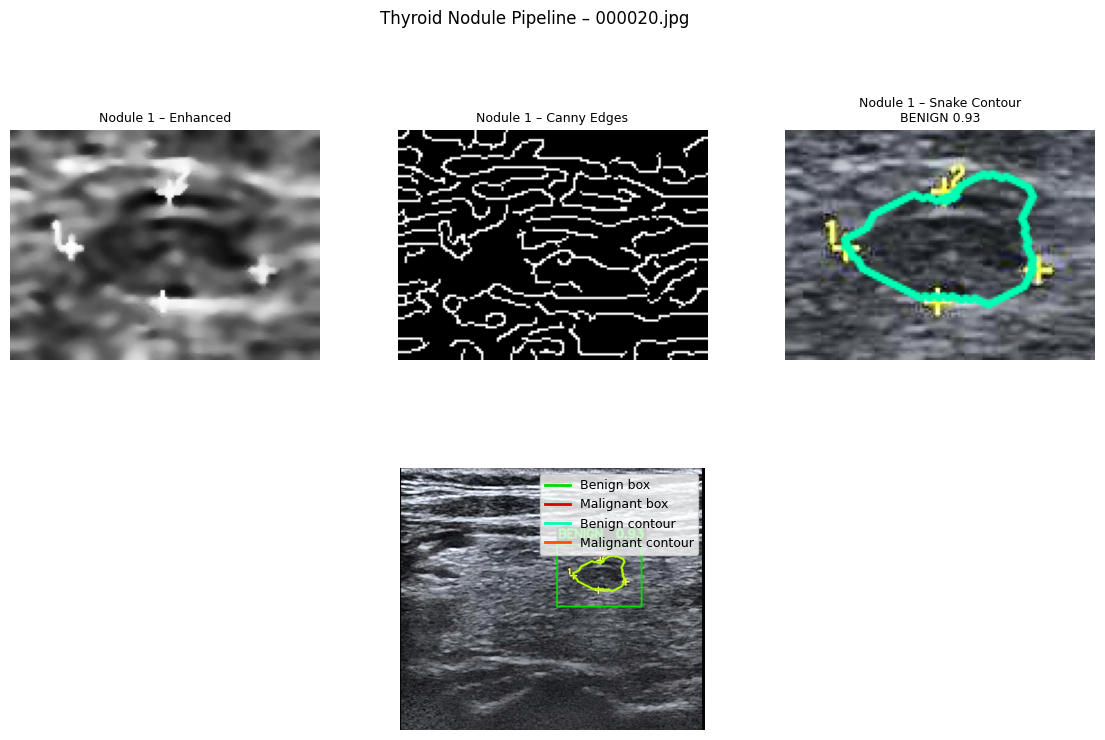


[Pipeline] Output saved to: E:\Github\Thyroid nodule detection\Data\000020_contour_result.jpg


In [24]:
# ── Run the extended pipeline ─────────────────────────────────────────────
print("Loading models...")
rcnn_model      = load_rcnn(RCNN_WEIGHTS_PATH)
densenet_models = load_densenet_ensemble(DENSENET_WEIGHTS_PATHS)
resnet_models   = load_resnet_ensemble(RESNET_WEIGHTS_PATHS)
print("\nAll models ready.")

img_path = r"E:\Github\Thyroid nodule detection\Data\000020.jpg"   # <- change this

results = run_pipeline_with_contour(
    image_path      = img_path,
    rcnn_model      = rcnn_model,
    densenet_models = densenet_models,
    resnet_models   = resnet_models,
    save_path       = img_path.replace(".jpg", "_contour_result.jpg"),
    verbose         = True,

    # ── Snake hyper-parameters ── tune these for your dataset ──
    snake_alpha  = 0.5,   # elasticity  (↑ rounder contour)
    snake_beta   = 0.2,   # curvature   (↑ stiffer/smoother)
    snake_gamma  = 2.0,   # edge pull   (↑ stronger attraction to Canny)
    snake_iters  = 300,   # max iterations
    snake_radius = 3,     # search window half-size (pixels)

    # ── Canny thresholds ── lower → more edges detected ────────
    canny_low    = 30,
    canny_high   = 80,

    n_points     = 120,   # control points on the ellipse
)
